**Customer Segmentation using K-Means Clustering**

Project Overview

This project segments customers based on income, spending, and purchasing behavior to support better business decisions.

1. Import required libraries for data handling, visualization, and clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

2. Upload Dataset from Local System

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ifood_df.csv to ifood_df.csv


3. Load the Dataset into a DataFrame

In [3]:
df = pd.read_csv("ifood_df.csv")
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


4. Explore Dataset Structure, Data Types, and Summary Statistics

In [4]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


5. Clean Data by Handling Missing Values and Removing Duplicates

In [5]:

df.isnull().sum()
df.fillna(df.mean(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

6. Create New Features to Better Represent Customer Behavior

In [6]:
df['Total_Purchases'] = df['NumWebPurchases'] + df['NumStorePurchases']
df['Customer_Value'] = df['Income'] * df['MntTotal']

7. Select Important Features for Customer Segmentation

In [7]:
features = df[['Income', 'Recency', 'MntTotal', 'Total_Purchases', 'Customer_Value']]

8. Scale Features to Ensure Equal Contribution to Clustering

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

9. Use Elbow Method to Determine Optimal Number of Clusters

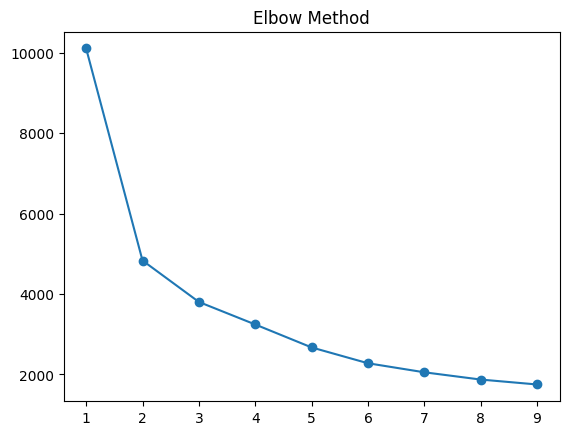

In [9]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss, marker='o')
plt.title("Elbow Method")
plt.show()


10. Apply K-Means Clustering to Segment Customers into Groups

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

11. Evaluate Clustering Performance Using Silhouette Score

In [11]:
from sklearn.metrics import silhouette_score

print(silhouette_score(scaled_data, clusters))

0.343054653120568


12. Visualize Customer Segments Using PCA for Dimensionality Reduction

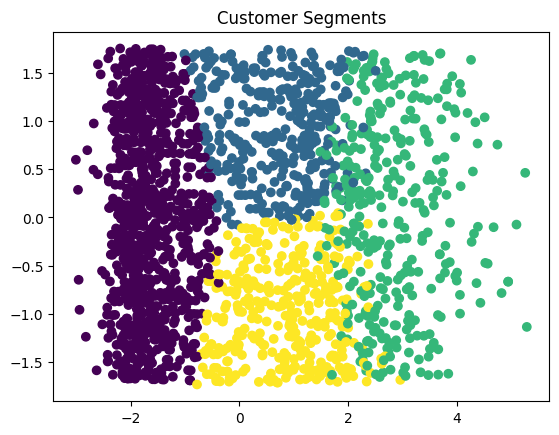

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters)
plt.title("Customer Segments")
plt.show()

13. Analyze Average Feature Values for Each Customer Cluster

In [13]:
df.groupby('Cluster').mean()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total_Purchases,Customer_Value
Cluster,,,,,,,,,,,,,,,,,,,,,
0,34041.285111,0.779303,0.466737,48.400211,44.270327,5.280887,26.081309,7.916579,5.408659,17.829989,...,0.105597,0.050686,0.488912,0.163675,0.191130,88.957761,71.127772,0.091869,5.404435,3.349939e+06
1,60823.495868,0.195592,0.691460,75.520661,409.057851,32.402204,175.732782,47.829201,36.297521,61.380165,...,0.066116,0.002755,0.512397,0.184573,0.234160,701.319559,639.939394,0.267218,13.449036,4.403416e+07
2,78874.974212,0.051576,0.229226,50.767908,798.621777,66.696275,518.724928,96.048711,69.575931,77.126074,...,0.065903,0.000000,0.527221,0.166189,0.240688,1549.667622,1472.541547,0.936963,13.865330,1.225665e+08
3,62476.679558,0.190608,0.709945,21.604972,415.165746,36.582873,182.546961,48.665746,34.613260,62.660221,...,0.099448,0.000000,0.502762,0.151934,0.245856,717.574586,654.914365,0.276243,14.406077,4.621629e+07


14. Visualize Distribution of Customers Across Clusters

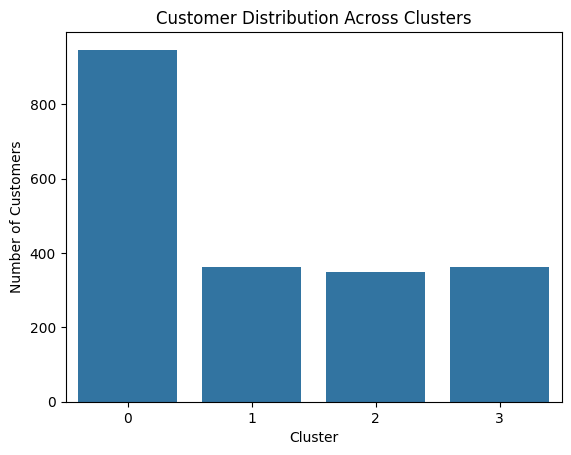

In [14]:
import seaborn as sns

sns.countplot(x='Cluster', data=df)
plt.title("Customer Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

15. Insights and Recommendations

- Cluster 0: High-value customers with strong purchasing behavior → Focus on retention through loyalty programs and exclusive offers  
- Cluster 1: Customers with moderate income but lower spending → Increase engagement using targeted promotions  
- Cluster 2: Customers with high income but inconsistent spending → Encourage activity with personalized marketing  
- Cluster 3: Low-value customers with minimal spending → Attract with discounts and cost-effective products  

These insights enable businesses to design targeted strategies and improve overall customer engagement.